# Adsorption Using AiiDAlab

### Group L : Taïs Thomas, Marouchka Heck, Marie-Caroline Bilocq

### 1. Describe the type of calculations AiiDAlab offers for adsorption studies

AiiDAlab offers three main types of calculations for adsorption studies:

- Geometry optimization and charges: This calculation prepares the framework for subsequent adsorption simulations by optimizing its geometry and assigning point charges to its atoms. These charges are important because electrostatic (Coulombic) interactions can influence the adsorption of molecules, particularly those with significant charge distributions. The structure can either be uploaded by the user or selected from the AiiDAlab database.

  Two computational codes are used in this process. First, CP2K performs the geometry optimization, for which resources such as the number of nodes and CPUs can be selected. Then, DDEC is used to assign atomic point charges to the optimized framework. Different calculation protocols are available depending on the complexity of the structure.



- Pore analysis: Pore analysis characterizes the pore structure of the material and is performed using the Zeo++ code. It is a geometrical calculation based on the crystal structure and a specified probe radius, without requiring a temperature or force field. It provides properties such as the density, accessible surface area (ASA), accessible probe-occupiable volume (POAV), and porosity. It also identifies accessible and inaccessible pores based on the specified probe radius and provides information about the number of channels and isolated pockets in the material.



- Isotherm calculations: This calculation uses a previously optimized framework to study the adsorption of a selected guest molecule at a specified temperature. The user can also choose or modify the force field.

  Two computational codes are involved. First, Zeo++ identifies pores that are geometrically inaccessible to the guest molecule. This is important because Monte Carlo simulations can otherwise attempt to insert molecules into regions that are not accessible from the outside. Zeo++ identifies these inaccessible regions and can generate blocking spheres to prevent molecules from being inserted into them during the Monte Carlo simulation.

  The second code, RASPA, performs Monte Carlo simulations to study the adsorption of the selected guest molecule inside the framework. These simulations are carried out at different pressures, allowing the average amount of gas adsorbed per unit mass of material (the loading) to be determined at each pressure.

  The resulting adsorption isotherm represents the loading as a function of pressure at a fixed temperature. It therefore allows us to study how the adsorption capacity of the material changes as the pressure increases.

  AiiDAlab can also calculate the Henry coefficient $K_H$ using RASPA and the Widom insertion method. The Henry coefficient describes adsorption in the low-pressure limit, where the loading $q$ is proportional to pressure:

  $$
  q = K_H P
  $$

  The Henry coefficient therefore corresponds to the initial slope of the adsorption isotherm and provides information about the affinity of a gas for the adsorbent. A larger Henry coefficient indicates stronger adsorption at low pressure. The calculation also provides the average adsorption energy, which gives additional information about the interactions between the guest molecule and the framework.

  While the Henry coefficient describes adsorption in the low-pressure regime, the full adsorption isotherm shows how the loading evolves over a wider pressure range, where the relationship between loading and pressure is not necessarily linear.

These three types of calculations are complementary: geometry optimization and charge assignment prepare the framework for molecular simulations, pore analysis characterizes its accessible pore structure, and isotherm calculations evaluate its adsorption behavior and capacity.

### 2. Compute the density ($\mathrm{g \cdot cm^{-3}}$), accessible surface area – ASA ($\mathrm{{A}^2}$), accessible probe-occupiable volume – POAV ($\mathrm{{A}^3}$), and porosity of the material (probe radius = $1.525\ \mathrm{\mathring{A}}$)

Using AiiDAlab with a probe radius of $1.525\ \mathrm{\mathring{A}}$, the pore analysis of IRMOF-1 gives:

| Property | Value |
|---|---:|
| Density | $0.576983\ \mathrm{g \cdot cm^{-3}}$ |
| Accessible surface area (ASA) | $3964.65\ \mathrm{{A}^2}$ |
| Probe-occupiable accessible volume (POAV) | $13737.4\ \mathrm{{A}^3}$ |
| Porosity (POAV Volume fraction) | $0.77498$ |

### 3. Compute the Henry coefficients for $CO_2$ and $CH_4$ at $300\ \mathrm{K}$. What can you deduce ?

At $300\ \mathrm{K}$, the average Henry coefficients obtained for $CO_2$ and $CH_4$ are:

$$K_H(\mathrm{CO_2}) = 4.95566 \times 10^{-6}\ \mathrm{mol \cdot kg^{-1} \cdot Pa^{-1}}$$

$$K_H(\mathrm{CH_4}) = 1.12008 \times 10^{-6}\ \mathrm{mol \cdot kg^{-1} \cdot Pa^{-1}}$$

We can compare these results by computing the ratio of the two Henry coefficients as follows:

$$\frac{K_H(\mathrm{CO_2})}{K_H(\mathrm{CH_4})}=\frac{4.95566 \times 10^{-6}}{1.12008 \times 10^{-6}}\approx 4.424$$

It is important to note that the use of Henry's law is only valid at low pressures. Therefore IRMOF-1 has a higher affinity for $CO_2$ than for $CH_4$ at low pressure, since the Henry coefficient of $CO_2$ is about $4.4$ times larger than that of $CH_4$. This means that the $CO_2$ molecules are better adsorbed by the metal organic framework than the $CH_4$ molecules, making IRMOF-1 appropriate for $CO_2$/$CH_4$ separation.

### 4. Compute the pure $CO_2$ and $CH_4$ adsorption isotherms at $300\ \mathrm{K}$ and plots of the results.

Firstly, we have printed the first few rows of the 871.csv file to check its structure and the column names.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [2]:
co2_output = pd.read_csv("871.csv")

co2_output.head()


,Key,Value
0,Density,0.576983
1,Density_unit,g/cm^3
2,Estimated_saturation_loading,26.78196
3,Estimated_saturation_loading_unit,mol/kg
4,Input_block,"[1.525, 100]"


In [3]:
ch4_output = pd.read_csv("417.csv")

ch4_output.head()

,Key,Value
0,Density,0.576983
1,Density_unit,g/cm^3
2,Estimated_saturation_loading,33.871344
3,Estimated_saturation_loading_unit,mol/kg
4,Input_block,"[1.865, 100]"


Now, we can plot the results by extracting the wanted values, which are the pressure and the loading absolute average. This last value represents the average amount of gas adsorbed inside the MOF at a given pressure.

In [4]:
co2_isotherm_data = ast.literal_eval(co2_output.loc[co2_output["Key"] == "isotherm", "Value"].iloc[0])

co2_pressure = co2_isotherm_data["pressure"]
co2_loading = co2_isotherm_data["loading_absolute_average"]

In [5]:
ch4_isotherm_data = ast.literal_eval(ch4_output.loc[ch4_output["Key"] == "isotherm", "Value"].iloc[0])

ch4_pressure = ch4_isotherm_data["pressure"]
ch4_loading = ch4_isotherm_data["loading_absolute_average"]

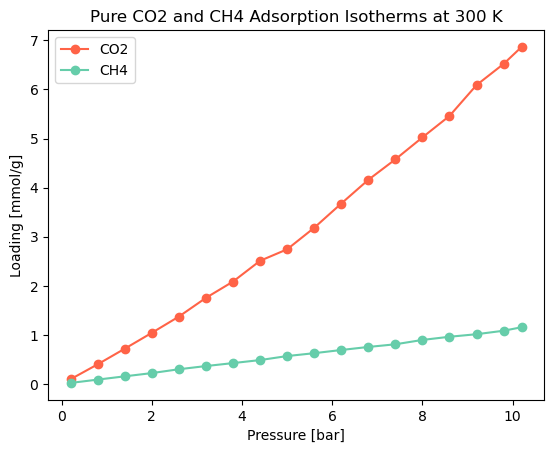

In [6]:
plt.plot(co2_pressure, co2_loading, "o-", color= "Tomato", label="CO2")
plt.plot(ch4_pressure, ch4_loading, "o-", color= "MediumAquamarine", label="CH4")

plt.xlabel("Pressure [bar]")
plt.ylabel("Loading [mmol/g]")
plt.title("Pure CO2 and CH4 Adsorption Isotherms at 300 K")
plt.legend()

plt.show()

The pure-component adsorption isotherms at $300\ \mathrm{K}$ show that the loading of both $CO_2$ and $CH_4$ increases with pressure. However, $CO_2$ is adsorbed in significantly larger amounts than $CH_4$ over the entire investigated pressure range. For example, at 10.2 bar and 300 K, the $CO_2$ loading reaches approximately 6.87 mmol/g, whereas the $CH_4$ loading is approximately 1.16 mmol/g.

This indicates a stronger affinity of IRMOF-1 for $CO_2$ than for $CH_4$, which is consistent with the Henry coefficients obtained in Question 3. At low pressure, the larger Henry coefficient of $CO_2$ already indicates stronger $CO_2$ adsorption, and the pure-component isotherms show that this difference persists as the pressure increases.

### 5. Use pyIAST to obtain the binary-mixture isotherms by the linear interpolation method for a pressure range from 0.1 to 4.0. Use increments of 0.2 and plot the results.

For this question, pyIAST is used to predict the adsorption of a gas mixture from the pure component adsorption isotherms. Here, the pure $CO_2$ and $CH_4$ isotherms obtained in question 4 are used to estimate the loading of each component where both gases are present simultaneously. To model the desired mixture for separation we use $y_{\mathrm{CO_2}} = 0.4$ and $y_{\mathrm{CH_4}} = 0.6$

In [7]:
%pip install pyiast

Note: you may need to restart the kernel to use updated packages.


Similarly as the previous question, the csv files are imported to extract the wanted values, which include the pressure and the loading absolute average.

In [8]:
import pyiast

co2_data = pd.read_csv("871.csv")
ch4_data = pd.read_csv("417.csv")

In [9]:
co2_isotherm_data = ast.literal_eval(co2_data.loc[co2_data["Key"] == "isotherm", "Value"].iloc[0])

ch4_isotherm_data = ast.literal_eval(ch4_data.loc[ch4_data["Key"] == "isotherm", "Value"].iloc[0])

co2_data = pd.DataFrame({"Pressure(bar)": co2_isotherm_data["pressure"],
    "Loading(mmol/g)": co2_isotherm_data["loading_absolute_average"]})

ch4_data = pd.DataFrame({"Pressure(bar)": ch4_isotherm_data["pressure"],
    "Loading(mmol/g)": ch4_isotherm_data["loading_absolute_average"]})

co2_isotherm = pyiast.InterpolatorIsotherm(co2_data,
    loading_key="Loading(mmol/g)",
    pressure_key="Pressure(bar)")

ch4_isotherm = pyiast.InterpolatorIsotherm(ch4_data,
    loading_key="Loading(mmol/g)",
    pressure_key="Pressure(bar)")

pressures = np.arange(0.1, 4.01, 0.2)

y_co2 = 0.4
y_ch4 = 0.6

pressures

array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.3, 2.5,
       2.7, 2.9, 3.1, 3.3, 3.5, 3.7, 3.9])

In [10]:
co2_loading = []
ch4_loading = []

for P in pressures:
    partial_pressures = [y_co2 * P, y_ch4 * P]

    loading = pyiast.iast(partial_pressures, [co2_isotherm, ch4_isotherm])

    co2_loading.append(loading[0])
    ch4_loading.append(loading[1])

results = pd.DataFrame({"Pressure (bar)": pressures,
    "CO2 Loading (mmol/g)": co2_loading,
    "CH4 Loading (mmol/g)": ch4_loading})

results

,Pressure (bar),CO2 Loading (mmol/g),CH4 Loading (mmol/g)
0,0.1,0.019718,0.006520
1,0.3,0.059267,0.019864
2,0.5,0.099177,0.033402
3,0.7,0.139356,0.046916
4,0.9,0.180099,0.060543
5,1.1,0.221800,0.074792
6,1.3,0.261597,0.088475
7,1.5,0.300998,0.101861
8,1.7,0.341861,0.115494
9,1.9,0.383767,0.129278


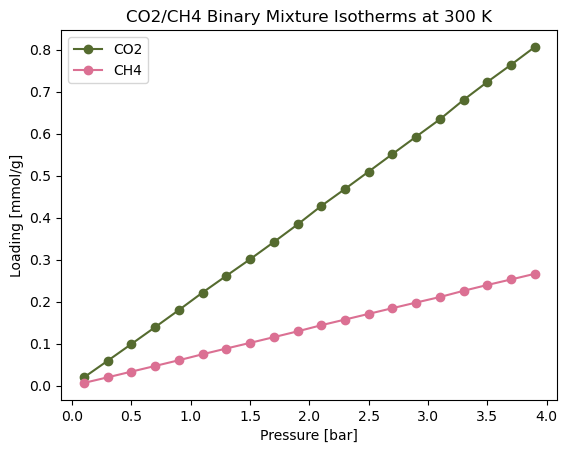

In [11]:
plt.plot(pressures, co2_loading, "o-", color= "DarkOliveGreen", label="CO2")
plt.plot(pressures, ch4_loading, "o-", color= "PaleVioletRed", label="CH4")

plt.xlabel("Pressure [bar]")
plt.ylabel("Loading [mmol/g]")
plt.title("CO2/CH4 Binary Mixture Isotherms at 300 K")
plt.legend()

plt.show()

The results show that the loading of both components increases with pressure. The adsorption loading is considered to evaluate the amount of $CO_2$ and $CH_4$ retained by IRMOF-1 as the pressure increases, providing a measure of the material’s adsorption capacity for each gas. However, the $CO_2$ loading is significantly higher than the $CH_4$ loading, indicating once again preferential adsorption of $CO_2$ in IRMOF-1.

This observation is also consistent with the Henry coefficients obtained in Question 3 and confirms that the adsorption of $CO_2$ is prefered.

### 6. Calculate the selectivity of $CO_2$ over $CH_4$ at 0.1, 1, 2 and 3 bars and 300 K. What can you deduce?

 The preferential adsorption of one gas over the other can be determined from the $CO_2$/$CH_4$ selectivity, which can be calculated using:

$$
S_{\mathrm{CO_2/CH_4}}
=
\frac{q_{\mathrm{CO_2}}}{q_{\mathrm{CH_4}}}
\frac{y_{\mathrm{CH_4}}}{y_{\mathrm{CO_2}}}
$$

where $q_i$ is the binary-mixture loading obtained from IAST in Question 5. We use the same gas-phase composition as in Question 5, with $y_{\mathrm{CO_2}} = 0.4$ and $y_{\mathrm{CH_4}} = 0.6$.

In [ ]:
selectivity_pressures = [0.1, 1.0, 2.0, 3.0]

selectivities = []

for P in selectivity_pressures:
    partial_pressures = [y_co2 * P, y_ch4 * P]

    loading = pyiast.iast(partial_pressures,
        [co2_isotherm, ch4_isotherm])

    q_co2 = loading[0]
    q_ch4 = loading[1]

    S = (q_co2 / q_ch4) * (y_ch4 / y_co2)

    selectivities.append(S)

In [14]:
selectivity_results = pd.DataFrame({
    "Pressure (bar)": selectivity_pressures,
    "CO2/CH4 Selectivity": selectivities
})

selectivity_results

,Pressure (bar),CO2/CH4 Selectivity
0,0.1,4.536158
1,1.0,4.457479
2,2.0,4.457047
3,3.0,4.500498


The $CO_2$/$CH_4$ selectivity remains approximately constant at around 4.5 over the investigated pressure range. Since the selectivity is greater than 1, IRMOF-1 preferentially adsorbs $CO_2$ over $CH_4$.

### 7. Prove that if $y_{\mathrm{CO_2}}$ drops to 0.2, the selectivity doesn’t change. What should we do to test if the selectivity is a function of temperature?

To test the effect of the gas-phase composition on the selectivity, the $CO_2$ mole fraction is decreased from 0.4 to 0.2. Since the mixture contains only $CO_2$ and $CH_4$, the $CH_4$ mole fraction becomes 0.8. The IAST calculations and selectivity calculations are then repeated at the same pressures as in Question 6.

In [15]:
y_co2_new = 0.2
y_ch4_new = 0.8

selectivities_new = []

for P in selectivity_pressures:
    partial_pressures = [y_co2_new * P, y_ch4_new * P]

    loading = pyiast.iast(
        partial_pressures,
        [co2_isotherm, ch4_isotherm]
    )

    q_co2 = loading[0]
    q_ch4 = loading[1]

    S = (q_co2 / q_ch4) * (y_ch4_new / y_co2_new)

    selectivities_new.append(S)

In [16]:
comparison = pd.DataFrame({
    "Pressure (bar)": selectivity_pressures,
    "Selectivity (y_CO2 = 0.4)": selectivities,
    "Selectivity (y_CO2 = 0.2)": selectivities_new
})

comparison

,Pressure (bar),Selectivity (y_CO2 = 0.4),Selectivity (y_CO2 = 0.2)
0,0.1,4.536158,4.538922
1,1.0,4.457479,4.455856
2,2.0,4.457047,4.432198
3,3.0,4.500498,4.459433


The selectivity values obtained for $y_{\mathrm{CO_2}} = 0.2$ are very similar to those obtained for $y_{\mathrm{CO_2}} = 0.4$.

This behavior can also be explained using Henry's law. At sufficiently low pressures, the loading of each gas is proportional to its partial pressure:

$$
q_i = K_{H,i} y_i P
$$

Substituting this expression into the definition of selectivity gives:

$$
S_{\mathrm{CO_2/CH_4}}
=
\frac{K_{H,\mathrm{CO_2}} y_{\mathrm{CO_2}} P}
{K_{H,\mathrm{CH_4}} y_{\mathrm{CH_4}} P}
\frac{y_{\mathrm{CH_4}}}{y_{\mathrm{CO_2}}}
$$

Simplifying:

$$
S_{\mathrm{CO_2/CH_4}}
=
\frac{K_{H,\mathrm{CO_2}}}{K_{H,\mathrm{CH_4}}}
$$

Therefore, in the Henry's law regime, the selectivity is independent of the gas-phase composition. This explains why decreasing the $CO_2$ mole fraction from 0.4 to 0.2 has little effect on the calculated selectivity. The IAST results confirm that the selectivities remain approximately unchanged over the investigated pressure range.

To determine whether the $CO_2$/$CH_4$ selectivity depends on temperature, pure-component $CO_2$ and $CH_4$ adsorption isotherms should be calculated at several different temperatures. IAST can then be applied at each temperature using the corresponding pure-component isotherms, and the resulting selectivities can be compared at the same pressures and gas-phase composition.

### 8. Explain if IRMOF-1 is a good or bad candidate for $CH_4$ storage.

The results obtained for IRMOF-1 show that the material has several structural properties that could make it interesting for gas storage. The results obtained in Question 2 (including density, POAV, ASA, porosity) indicate that IRMOF-1 has favorable structural properties for gas adsorption, including a large accessible pore volume that provides sufficient space for gas molecules to enter and be adsorbed within the material.

However, the pore structure alone is not enough to determine whether IRMOF-1 is a good material for $CH_4$ storage. 

The adsorption results obtained at 300 K in Question 3 show that the interaction between IRMOF-1 and $CH_4$ is relatively weak compared to the one with $CO_2$. The Henry coefficient calculated for $CH_4$ is 1.12008 × 10⁻⁶ mol·kg⁻¹·Pa⁻¹. In comparison, the Henry coefficient obtained for $CO_2$ is 4.95566 × 10⁻⁶ mol·kg⁻¹·Pa⁻¹, which is approximately 4.4 times larger than the value obtained for $CH_4$. Since a lower Henry coefficient indicates a lower affinity of the adsorbent for the gas at low pressure, the lower value for $CH_4$ means that $CH_4$ is less strongly adsorbed by IRMOF-1 under these conditions.

This difference is also visible in the pure-component adsorption isotherms calculated at 300 K in Question 4. Here, the pure-component adsorption isotherms describe the amount of one of the gases adsorbed by IRMOF-1 as a function of pressure at a constant temperature of 300 K. Moreover, the amount of gas that can actually be stored depends on how much its loading increases with pressure. Although the loading of $CH_4$ increases with increasing pressure, the amount of $CH_4$ adsorbed is significantly lower than the amount of $CO_2$ adsorbed. This means that, even though the porous structure provides a large space for gas adsorption, the amount of methane taken up by IRMOF-1 is limited under the conditions studied.

For the binary mixture containing 40% $CO_2$ and 60% $CH_4$, the IAST calculations performed in Question 5 also show a higher adsorption of $CO_2$. Indeed, the $CO_2$ loading is higher than the $CH_4$ loading. The calculated $CO_2$/$CH_4$ selectivity is approximately 4.5 at 0.1, 1, 2, and 3 bar. A selectivity higher than 1 indicates that $CO_2$ is preferentially adsorbed over $CH_4$. Since the selectivity remains relatively constant between 0.1 and 3 bar, the preference for $CO_2$ does not change significantly with pressure.

The results from Question 7 further support this behavior. When the gas composition is changed from 40:60 to 20:80 ($CO_2$:$CH_4$), the calculated $CO_2$/$CH_4$ selectivity remains very similar. Therefore, even when the gas mixture contains a larger proportion of $CH_4$, IRMOF-1 still shows a clear preference for $CO_2$. This is unfavorable for $CH_4$ storage because the material preferentially adsorbs $CO_2$ rather than $CH_4$.

Overall, IRMOF-1 has several properties that are favorable for gas storage, such as its high porosity, large accessible surface area, and large accessible volume. However, these structural properties do not translate into particularly strong adsorption of $CH_4$. At 300 K, $CH_4$ has a lower Henry coefficient than $CO_2$, a lower loading in the pure-component isotherm, and IRMOF-1 preferentially adsorbs $CO_2$ over $CH_4$ in a mixture. Therefore, although IRMOF-1 has a porous structure that could accommodate a significant amount of gas, its relatively weak affinity for $CH_4$ suggests that its methane storage performance is limited under the conditions studied. The material would be more suitable for applications such as $CO_2$ adsorption or $CO_2$/$CH_4$ separation rather than $CH_4$ storage.